In [31]:
from warcio.archiveiterator import ArchiveIterator
from pathlib import Path 
from collections import Counter

import matplotlib.pyplot as plt
from datetime import datetime


In [6]:
# Chemin vers le fichier WARC
WARC_PATH = Path("../data/raw/bnf-marsactu-2011-2015.pfvd.ux.bnf.fr.warc.gz")

if WARC_PATH.exists():
    print("Fichier trouvé !!")
    taille_mo = WARC_PATH.stat().st_size / (1024**2)
    print(f"Taille du fichier: {taille_mo: .1f} Mo")
else:
    print("Fichier non trouvé !!")
   

Fichier trouvé !!
Taille du fichier:  419.5 Mo


In [23]:
# Nombre de records
# Types de records

nb_records = 0
record_types_counter = Counter()

with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        
        nb_records += 1
        
        record_types_counter[f"{record.rec_type}"] += 1
        

        

print(f"Nombre total de records: {nb_records}")
print(record_types_counter.most_common(4))


Nombre total de records: 23470
[('response', 23469), ('warcinfo', 1)]


In [26]:
# Lecture du warcinfo
warcinfo_contenu = ""
with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type == "warcinfo":
            contenu_bytes = record.content_stream().read()
            contenu_texte = contenu_bytes.decode("utf-8")
            warcinfo_contenu.join(contenu_texte)
            print(contenu_texte)

hostname: delaware.pfvd.ux.bnf.fr
software: website-recover/3.0.0PFC30
ip: 172.20.90.124
format: WARC File Format 1.0
publisher: Bibliotheque nationale de France
description: Ce corpus correspond aux premières archives du site marsactu.fr constituées par la Bibliothèque nationale de France entre le 1er janvier 2011et le 31 décembre 2015.
conformsTo: http://bibnum.bnf.fr/WARC/WARC_ISO_28500_version1_latestdraft.pdf
operator: BnF - DLWeb



Nombre de dates collectées : 23469
Première capture : 2011-09-16 18:19:10
Dernière capture : 2015-12-30 14:26:27


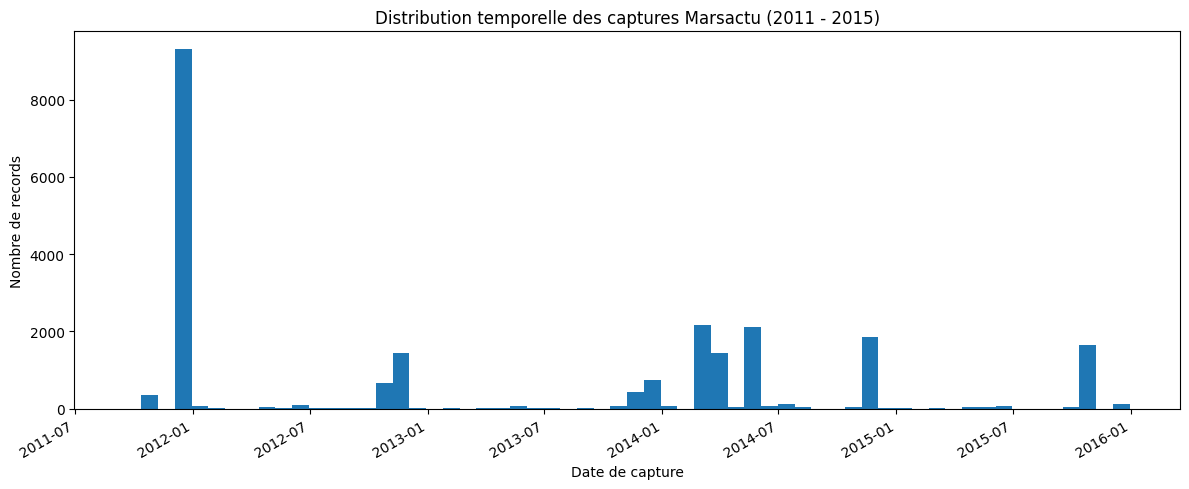

In [41]:
# Distribution temporelle des captures

dates_captures = []

with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type == "warcinfo":
            continue
        date_str = record.rec_headers.get_header("WARC-Date")
        date_obj = datetime.fromisoformat(date_str.replace("Z", ""))
        dates_captures.append(date_obj)
        


print(f"Nombre de dates collectées : {len(dates_captures)}")
print(f"Première capture : {min(dates_captures)}")
print(f"Dernière capture : {max(dates_captures)}")                              
                                
fig, ax = plt.subplots(figsize=(12,5))

ax.hist(dates_captures, bins=60)
ax.set_title("Distribution temporelle des captures Marsactu (2011 - 2015)")
ax.set_xlabel("Date de capture")
ax.set_ylabel("Nombre de records")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()
                                                 

                                                 
                                                 

        

# Remarque: 
Le corpus j1 de Marsactu présente une distribution temporelle très inégale, avec environ 40% des records enregistrés en janvier 2012, suggérant que la BNF ait fait une capture initiale massive de l'intégralité du site Marsactu existant à ce moment-là. L'analyse diachronique ne devra pas reposer sur la date de capture mais plutôt sur la date de publication de la page HTML des articles.

In [52]:
# Vérifions que la conjecture faite sur la capture du Janvier 2012 soit une capture massive. 

echantillons_jan_2012 = []
with open(WARC_PATH, 'rb') as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type != "response":
            continue
            
        date_str = record.rec_headers.get_header("WARC-Date")

        if not date_str.startswith("2012-01"):
            continue

        url = record.rec_headers.get_header("WARC-Target-URI")

        html_bytes = record.content_stream().read()

        echantillons_jan_2012.append({
            "url": url,
            "date_capture": date_str, 
            "html": html_bytes
        })

        if len(echantillons_jan_2012) >= 20:
            break


print(f"echantillons collectés: {len(echantillons_jan_2012)}")
            

        

echantillons collectés: 20


In [51]:
for i, ech in enumerate(echantillons_jan_2012):
    print(f"[{i}] {ech['date_capture']} -> {ech['url']}")


[0] 2012-01-24T11:28:46Z -> http://www.marsactu.fr/2009/12/17/nathalie-simon-retrouve-lantenne/feed/
[1] 2012-01-24T11:29:03Z -> http://www.marsactu.fr/2009/12/22/le-tribunal-administratif-de-marseille-renvoie-michel-drucker-dans-son-canape/
[2] 2012-01-29T16:08:39Z -> http://www.marsactu.fr/2010/02/17/christophe-madrolle-va-t-il-traverser-le-vieux-port-a-la-nage/feed/
[3] 2012-01-29T16:09:14Z -> http://www.marsactu.fr/2010/02/17/des-musulmans-se-mobilisent-pour-restaurer-une-chapelle/
[4] 2012-01-29T16:08:48Z -> http://www.marsactu.fr/2010/02/17/margarita-louis-dreyfus-va-t-elle-preferer-lom-aux-paris-en-ligne/
[5] 2012-01-23T20:39:00Z -> http://www.marsactu.fr/2011/01/07/affaire-guerini-la-petite-fleur-objet-de-toutes-les-attentions-du-cg13/feed/
[6] 2012-01-23T20:45:33Z -> http://www.marsactu.fr/2011/01/07/cantonales-affaire-guerini-wikileaks13-menu-charge-pour-les-voeux-du-conseil-general/
[7] 2012-01-23T20:39:58Z -> http://www.marsactu.fr/2011/01/07/le-ras-le-bol-des-gens-du-voyag

In [53]:
print(echantillons_jan_2012[8]['url'])
print(echantillons_jan_2012[8]['html'])

http://www.marsactu.fr/2011/01/07/le-ras-le-bol-des-gens-du-voyage-devant-la-mairie-de-marseille/feed/
b'<?xml version="1.0" encoding="UTF-8"?><rss version="2.0" xmlns:content="http://purl.org/rss/1.0/modules/content/" xmlns:dc="http://purl.org/dc/elements/1.1/" xmlns:atom="http://www.w3.org/2005/Atom" xmlns:sy="http://purl.org/rss/1.0/modules/syndication/" xmlns:georss="http://www.georss.org/georss" xmlns:media="http://search.yahoo.com/mrss/"\t> <channel><title>Commentaires sur : Le ras-le-bol des gens du voyage devant la mairie de Marseille</title> <atom:link href="http://www.marsactu.fr/2011/01/07/le-ras-le-bol-des-gens-du-voyage-devant-la-mairie-de-marseille/feed/" rel="self" type="application/rss+xml" /><link>http://www.marsactu.fr/2011/01/07/le-ras-le-bol-des-gens-du-voyage-devant-la-mairie-de-marseille/</link> <description>24/24 Le quotidien de Marseille qui ne s&#039;arr\xc3\xaate jamais</description> <lastBuildDate>Mon, 23 Jan 2012 19:06:38 +0000</lastBuildDate> <sy:updatePeri

On retrouve des pages capturés datant de 2009 à 2011. On peut donc supposer que la capture du Janvier 2012 était une capture de toute l'historique de Marsactu.

# Remarque: 
Certaines de ces URLs finissent par "/feed/", ce sont des flux RSS (really simple syndication), c'est une version d'un site web interprétable par une machine. C'est un fichier au format XML qui liste les articles récents d'un site, de manière structurée, pour que d'autres outils puissent les lire automatiquement.
Pour faire simple si l'on visite "marsactu.fr/un-article/", on atteri sur le site orinal tel qu'il (images, article ...). 
Par contre si l'on visite "marsactu.fr/un-article/feed/", on tombe sur un fichier XML brut, sans mise en page, avec les informations du site, et un lien vers le site 



   

